In [1]:
'''Exercise 1 – Build Your MLP Using TensorFlow
Create the same 2-layer MLP using TensorFlow/Keras.

Step 1 – Import Libraries'''
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.21.0


In [2]:
'''Step 2 – Create a Small Dataset
Let's predict Pass (1) or Fail (0) based on:
Study Hours
Attendance'''
import numpy as np

X = np.array([
    [2, 50],
    [3, 60],
    [4, 65],
    [5, 70],
    [6, 75],
    [7, 80],
    [8, 85],
    [9, 90]
])

y = np.array([
    0,
    0,
    0,
    0,
    1,
    1,
    1,
    1
])

In [3]:
'''Step 3 – Build the Neural Network'''
model = Sequential([
    Dense(4, activation="relu", input_shape=(2,)),
    Dense(1, activation="sigmoid")
])

'''Explanation:
Input (2 Features)
↓
Hidden Layer (4 Neurons)
↓
Output Layer (1 Neuron)'''

C:\Users\rebi3\anaconda3\envs\DeepLearn\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


'Explanation:\nInput (2 Features)\n↓\nHidden Layer (4 Neurons)\n↓\nOutput Layer (1 Neuron)'

In [4]:
'''Step 4 – View the Model'''
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 4)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17 (68.00 B)

 Trainable params: 17 (68.00 B)

 Non-trainable params: 0 (0.00 B)

In [5]:
'''Step 5 – Compile the Model'''
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [6]:
'''Step 6 – Train the Model'''
history = model.fit(
    X,
    y,
    epochs=100,
    verbose=1
)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.5000 - loss: 26.9914
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.5000 - loss: 26.8823
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.5000 - loss: 26.7735
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.5000 - loss: 26.6650
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.5000 - loss: 26.5567
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.5000 - loss: 26.4488
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.5000 - loss: 26.3411
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.5000 - loss: 26.2337
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.5000 - loss: 26.1266
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.5000 - loss: 26.0198
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.5000 - loss: 25.9133
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.

In [7]:
'''Step 7 – Make Predictions'''
prediction = model.predict(X)
print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step
[[1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]]


In [8]:
'''These are probabilities.
Anything above 0.5 is classified as Pass.'''

'These are probabilities.\nAnything above 0.5 is classified as Pass.'

In [9]:
'''Step 8 – Predict a New Student'''
new_student = np.array([[7, 78]])

prediction = model.predict(new_student)

print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
[[1.]]


In [10]:
'''Exercise 2 – Model with Mean Squared Error'''
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Dataset
X = np.array([
    [2,50],
    [3,60],
    [4,65],
    [5,70],
    [6,75],
    [7,80],
    [8,85],
    [9,90]
])

y = np.array([0,0,0,0,1,1,1,1])

# Model
model_mse = Sequential([
    Dense(4, activation='relu', input_shape=(2,)),
    Dense(1, activation='sigmoid')
])

model_mse.compile(
    optimizer='adam',
    loss='mse',
    metrics=['accuracy']
)

history_mse = model_mse.fit(
    X,
    y,
    epochs=100,
    verbose=0
)

# Evaluate
loss_mse, acc_mse = model_mse.evaluate(X, y, verbose=0)

print("===== MSE MODEL =====")
print("Loss :", loss_mse)
print("Accuracy :", acc_mse)



===== MSE MODEL =====
Loss : 0.5
Accuracy : 0.5


In [11]:
'''Make Predictions with SME '''
print("\nPredictions:")
print(model_mse.predict(X))


Predictions:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
[[1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]]


In [12]:
'''Exercise 3 - import TensorFlow's SGD optimizer, SGD is Gradient Descent (technically stochastic gradient descent).'''
from tensorflow.keras.optimizers import SGD

optimizer = SGD(learning_rate=0.01)

In [13]:
'''Exercise 4 – build model with Gradient Descent'''
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD
import matplotlib.pyplot as plt

# Dataset
X = np.array([
    [2,50],
    [3,60],
    [4,65],
    [5,70],
    [6,75],
    [7,80],
    [8,85],
    [9,90]
], dtype=np.float32)

# Normalize
X[:,0] = X[:,0] / 9
X[:,1] = X[:,1] / 90

y = np.array([0,0,0,0,1,1,1,1], dtype=np.float32)

# Model
model = Sequential([
    Dense(4, activation='relu', input_shape=(2,)),
    Dense(1, activation='sigmoid')
])

# Gradient Descent Optimizer
optimizer = SGD(learning_rate=0.01)

model.compile(
    optimizer=optimizer,
    loss='mse',
    metrics=['accuracy']
)

history = model.fit(
    X,
    y,
    epochs=100,
    verbose=1
)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 541ms/step - accuracy: 0.1250 - loss: 0.2652
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.1250 - loss: 0.2651
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.1250 - loss: 0.2650
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.1250 - loss: 0.2649
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.1250 - loss: 0.2649
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.1250 - loss: 0.2648
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.1250 - loss: 0.2647
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.1250 - loss: 0.2646
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.1250 - loss: 0.2646
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.1250 - loss: 0.2645
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.1250 - loss: 0.2644
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.1250 - l

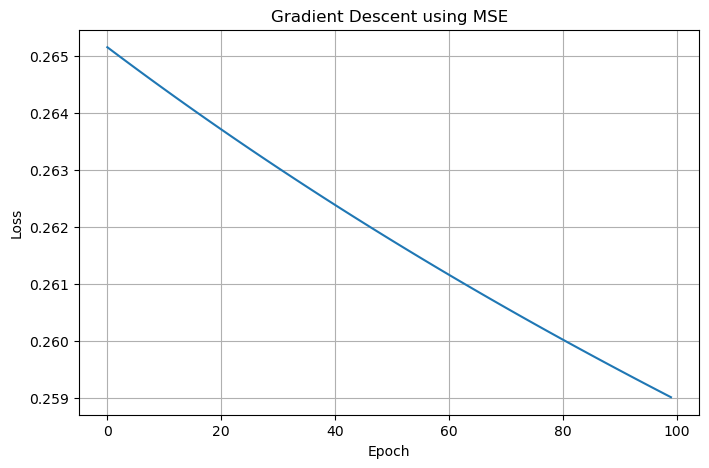

In [14]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'])

plt.title("Gradient Descent using MSE")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.grid()

plt.show()